In [1]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import os

In [2]:
# Load shapefile for counties/states
states = gpd.read_file(r'/Users/dsabatus/Documents/Tianle/coutinuous states_county level')

# Load merged hearing data with absolute number of audiologists
merged_df = pd.read_csv(r'/Users/dsabatus/Documents/Tianle/my_code/Merged_Hearing_Data_unique.csv')

In [3]:
# Merge shapefile with the data on FIPS
# Make sure FIPS is same type in both
states['FIPS'] = states['FIPS'].astype(int)
merged_df['FIPS'] = merged_df['FIPS'].astype(int)

gdf = states.merge(merged_df, on='FIPS', how='left') # merged df

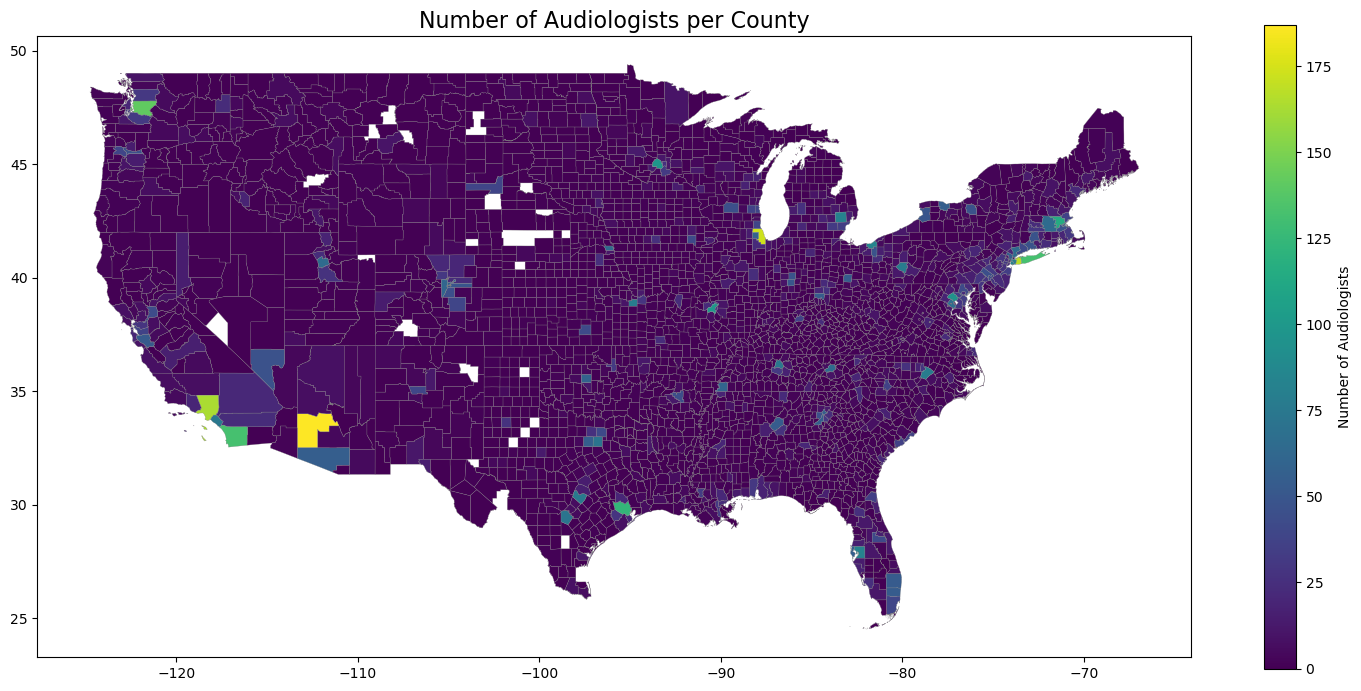

In [4]:
# Plot using GeoPandas only
fig, ax = plt.subplots(figsize=(15, 12))
gdf.plot(
    column='Abs_audiologists',
    cmap='viridis',
    edgecolor='gray',
    linewidth=0.2,
    ax=ax,
    legend=True,
    legend_kwds={'shrink': 0.55, 'label': 'Number of Audiologists'}
)
plt.title("Number of Audiologists per County", fontsize=16)
plt.tight_layout()

save_dir = "/Users/dsabatus/Documents/Tianle/my_code/"
plt.savefig(os.path.join(save_dir, "Audiologist1.png"), dpi=300, bbox_inches="tight")

plt.show()


In [5]:
print(merged_df)

       FIPS  MildHL_crd_rate  ModSev_crd_rate                 CountyState  \
0      1001          0.09363          0.04390     Autauga County, Alabama   
1      1003          0.09618          0.05149     Baldwin County, Alabama   
2      1005          0.10164          0.04964     Barbour County, Alabama   
3      1007          0.09593          0.04331        Bibb County, Alabama   
4      1009          0.09581          0.04899      Blount County, Alabama   
...     ...              ...              ...                         ...   
3085  56037          0.10804          0.04262  Sweetwater County, Wyoming   
3086  56039          0.06418          0.03181       Teton County, Wyoming   
3087  56041          0.10747          0.04616       Uinta County, Wyoming   
3088  56043          0.12578          0.06233    Washakie County, Wyoming   
3089  56045          0.12737          0.06249      Weston County, Wyoming   

      audiologists_per_10k  HighRiskOccupation  Population  Demog_age_0_14 

In [6]:
print(gdf)

      ST    STATE ST_ABBR STCNTY      COUNTY   FIPS  \
0     01  Alabama      AL  01001     Autauga   1001   
1     01  Alabama      AL  01003     Baldwin   1003   
2     01  Alabama      AL  01005     Barbour   1005   
3     01  Alabama      AL  01007        Bibb   1007   
4     01  Alabama      AL  01009      Blount   1009   
...   ..      ...     ...    ...         ...    ...   
3102  56  Wyoming      WY  56037  Sweetwater  56037   
3103  56  Wyoming      WY  56039       Teton  56039   
3104  56  Wyoming      WY  56041       Uinta  56041   
3105  56  Wyoming      WY  56043    Washakie  56043   
3106  56  Wyoming      WY  56045      Weston  56045   

                        LOCATION     AREA_SQMI  E_TOTPOP  M_TOTPOP  ...  \
0        Autauga County, Alabama    594.455838     55639         0  ...   
1        Baldwin County, Alabama   1589.835294    218289         0  ...   
2        Barbour County, Alabama    885.007618     25026         0  ...   
3           Bibb County, Alabama    622

C:\Users\dsabatus\AppData\Local\Temp\ipykernel_10636\3241486915.py:23: UserWarning: Only specify one of 'column' or 'color'. Using 'color'.
  gdf.plot(


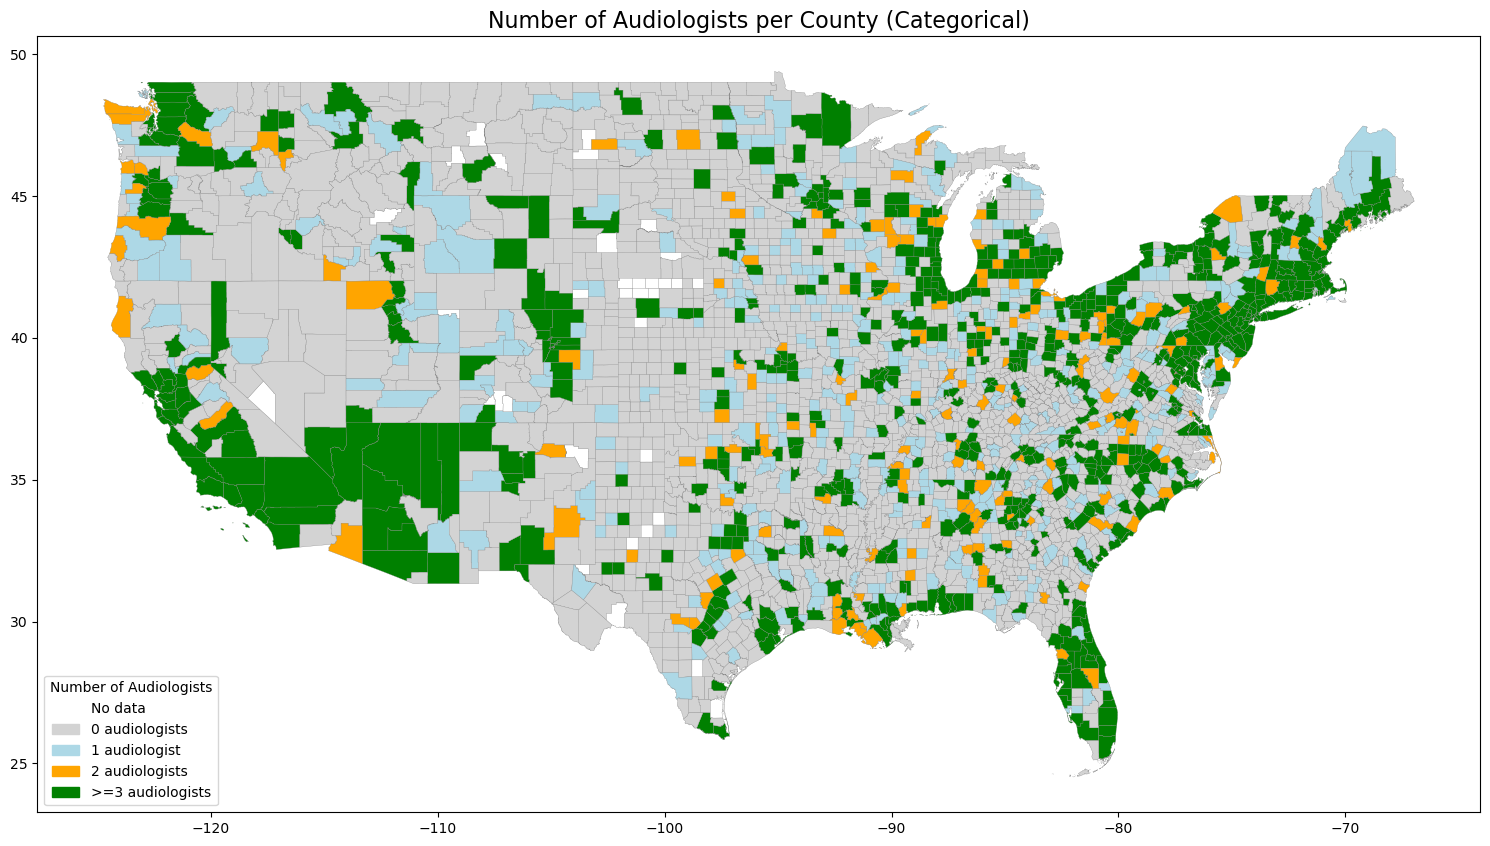

In [7]:
import matplotlib.patches as mpatches

# Create categorical column including NaN
def categorize_audiologists(x):
    if pd.isna(x):
        return 'NoData'
    elif x == 0:
        return '0'
    elif x == 1:
        return '1'
    elif x == 2:
        return '2'
    else:
        return '>=3'

gdf['Audiologist_category'] = gdf['Abs_audiologists'].apply(categorize_audiologists)

# Define colors
colors = {'NoData': 'white', '0': 'lightgray', '1': 'lightblue', '2': 'orange', '>=3': 'green'}

# Plot counties
fig, ax = plt.subplots(figsize=(15, 12))
gdf.plot(
    column='Audiologist_category',
    categorical=True,
    color=gdf['Audiologist_category'].map(colors),
    edgecolor='gray',
    linewidth=0.2,
    ax=ax
)

# Create custom legend
legend_patches = [
    mpatches.Patch(color='white', label='No data'),
    mpatches.Patch(color='lightgray', label='0 audiologists'),
    mpatches.Patch(color='lightblue', label='1 audiologist'),
    mpatches.Patch(color='orange', label='2 audiologists'),
    mpatches.Patch(color='green', label='>=3 audiologists')
]
ax.legend(handles=legend_patches, title="Number of Audiologists", loc='lower left')

plt.title("Number of Audiologists per County (Categorical)", fontsize=16)
plt.tight_layout()
plt.show()



In [8]:
print(states.head())

   ST    STATE ST_ABBR STCNTY   COUNTY  FIPS                 LOCATION  \
0  01  Alabama      AL  01001  Autauga  1001  Autauga County, Alabama   
1  01  Alabama      AL  01003  Baldwin  1003  Baldwin County, Alabama   
2  01  Alabama      AL  01005  Barbour  1005  Barbour County, Alabama   
3  01  Alabama      AL  01007     Bibb  1007     Bibb County, Alabama   
4  01  Alabama      AL  01009   Blount  1009   Blount County, Alabama   

     AREA_SQMI  E_TOTPOP  M_TOTPOP  ...  MP_AIAN  EP_NHPI  MP_NHPI  \
0   594.455838     55639         0  ...      0.2      0.0      0.1   
1  1589.835294    218289         0  ...      0.2      0.0      0.1   
2   885.007618     25026         0  ...      0.3      0.0      0.1   
3   622.469288     22374         0  ...      0.1      0.0      0.2   
4   644.890375     57755         0  ...      0.1      0.1      0.1   

   EP_TWOMORE  MP_TWOMORE  EP_OTHERRA  MP_OTHERRA  SHAPE_STAr  SHAPE_STLe  \
0         2.0         0.7         0.2         0.3    0.150259  

In [9]:
# Filter counties with more than 1000 audiologists
high_audiologist_counties = merged_df[merged_df["Abs_audiologists"] > 100]

# Check the result
print(high_audiologist_counties[["CountyState", "Abs_audiologists"]])
print(f"Number of counties with >100 audiologists: {high_audiologist_counties.shape[0]}")

                            CountyState  Abs_audiologists
75    Matanuska-Susitna Borough, Alaska               248
87             Maricopa County, Arizona               187
188      Los Angeles County, California               163
206        San Diego County, California               132
589               Cook County, Illinois               173
1204    Middlesex County, Massachusetts               114
1819            Nassau County, New York               168
1841           Suffolk County, New York               132
2580               Harris County, Texas               124
2917            King County, Washington               141
Number of counties with >100 audiologists: 10


C:\Users\dsabatus\AppData\Local\Temp\ipykernel_10636\2572326472.py:19: UserWarning: Only specify one of 'column' or 'color'. Using 'color'.
  gdf.plot(


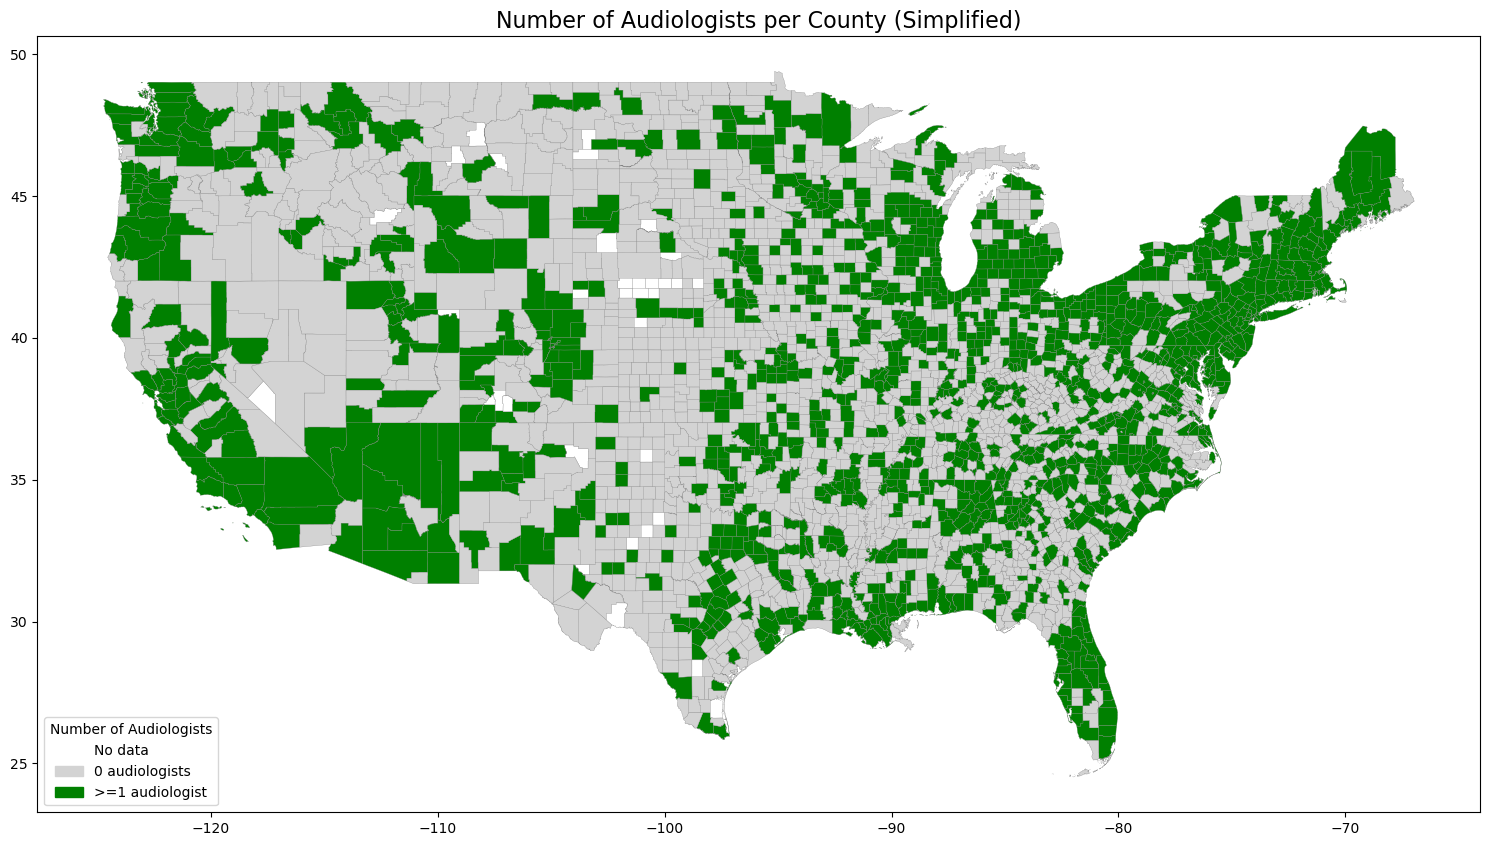

In [10]:
import matplotlib.patches as mpatches

# Create simplified categorical column
def categorize_audiologists_simple(x):
    if pd.isna(x):
        return 'NoData'
    elif x == 0:
        return '0'
    else:
        return '>=1'

gdf['Audiologist_category_simple'] = gdf['Abs_audiologists'].apply(categorize_audiologists_simple)

# Define colors for the three categories
colors_simple = {'NoData': 'white', '0': 'lightgray', '>=1': 'green'}

# Plot counties
fig, ax = plt.subplots(figsize=(15, 12))
gdf.plot(
    column='Audiologist_category_simple',
    categorical=True,
    color=gdf['Audiologist_category_simple'].map(colors_simple),
    edgecolor='gray',
    linewidth=0.2,
    ax=ax
)

# Create custom legend
legend_patches = [
    mpatches.Patch(color='white', label='No data'),
    mpatches.Patch(color='lightgray', label='0 audiologists'),
    mpatches.Patch(color='green', label='>=1 audiologist')
]
ax.legend(handles=legend_patches, title="Number of Audiologists", loc='lower left')

plt.title("Number of Audiologists per County (Simplified)", fontsize=16)
plt.tight_layout()

save_dir = "/Users/dsabatus/Documents/Tianle/my_code/"
plt.savefig(os.path.join(save_dir, "Audiologist2.png"))

plt.show()


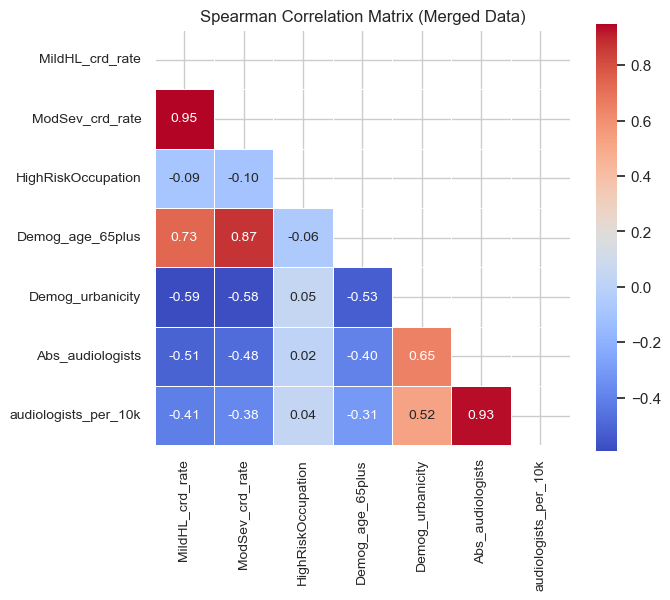

In [11]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Columns of interest
columns_of_interest = [
    'MildHL_crd_rate',
    'ModSev_crd_rate',
    'HighRiskOccupation',
    'Demog_age_65plus',
    'Demog_urbanicity',
    'Abs_audiologists',
    'audiologists_per_10k'
]

# Compute Spearman correlation matrix
spearman_corr_matrix = merged_df[columns_of_interest].corr(method='spearman')

# Mask the upper triangle
mask = np.triu(np.ones_like(spearman_corr_matrix, dtype=bool))

# Set Seaborn style
sns.set(style="whitegrid")

# Create figure with adjusted size
plt.figure(figsize=(7, 6))

# Plot heatmap
ax = sns.heatmap(
    spearman_corr_matrix, 
    annot=True, 
    cmap='coolwarm', 
    linewidths=.5, 
    fmt=".2f",
    annot_kws={'size': 10},
    mask=mask,
    square=True
)

# Axis label formatting
plt.xticks(rotation=90)
plt.yticks(rotation=0)  
ax.tick_params(axis='x', labelsize=10)  
ax.tick_params(axis='y', labelsize=10)

# Add title
plt.title('Spearman Correlation Matrix (Merged Data)', fontsize=12)

plt.tight_layout()


save_dir = "/Users/dsabatus/Documents/Tianle/my_code/"
plt.savefig(os.path.join(save_dir, "Correlation_Matrix.png"))

plt.show()

In [71]:
print(gdf.columns.tolist())

['ST', 'STATE', 'ST_ABBR', 'STCNTY', 'COUNTY', 'FIPS', 'LOCATION', 'AREA_SQMI', 'E_TOTPOP', 'M_TOTPOP', 'E_HU', 'M_HU', 'E_HH', 'M_HH', 'E_POV150', 'M_POV150', 'E_UNEMP', 'M_UNEMP', 'E_HBURD', 'M_HBURD', 'E_NOHSDP', 'M_NOHSDP', 'E_UNINSUR', 'M_UNINSUR', 'E_AGE65', 'M_AGE65', 'E_AGE17', 'M_AGE17', 'E_DISABL', 'M_DISABL', 'E_SNGPNT', 'M_SNGPNT', 'E_LIMENG', 'M_LIMENG', 'E_MINRTY', 'M_MINRTY', 'E_MUNIT', 'M_MUNIT', 'E_MOBILE', 'M_MOBILE', 'E_CROWD', 'M_CROWD', 'E_NOVEH', 'M_NOVEH', 'E_GROUPQ', 'M_GROUPQ', 'EP_POV150', 'MP_POV150', 'EP_UNEMP', 'MP_UNEMP', 'EP_HBURD', 'MP_HBURD', 'EP_NOHSDP', 'MP_NOHSDP', 'EP_UNINSUR', 'MP_UNINSUR', 'EP_AGE65', 'MP_AGE65', 'EP_AGE17', 'MP_AGE17', 'EP_DISABL', 'MP_DISABL', 'EP_SNGPNT', 'MP_SNGPNT', 'EP_LIMENG', 'MP_LIMENG', 'EP_MINRTY', 'MP_MINRTY', 'EP_MUNIT', 'MP_MUNIT', 'EP_MOBILE', 'MP_MOBILE', 'EP_CROWD', 'MP_CROWD', 'EP_NOVEH', 'MP_NOVEH', 'EP_GROUPQ', 'MP_GROUPQ', 'EPL_POV150', 'EPL_UNEMP', 'EPL_HBURD', 'EPL_NOHSDP', 'EPL_UNINSU', 'SPL_THEME1', 'RPL_T

In [12]:
# Select specific columns
subset = gdf[['COUNTY', 'FIPS','AREA_SQMI', 'E_TOTPOP', 'M_TOTPOP', 'Abs_audiologists']]

# Print the subset
print(subset)


          COUNTY   FIPS     AREA_SQMI  E_TOTPOP  M_TOTPOP  Abs_audiologists
0        Autauga   1001    594.455838     55639         0               2.0
1        Baldwin   1003   1589.835294    218289         0              17.0
2        Barbour   1005    885.007618     25026         0               0.0
3           Bibb   1007    622.469288     22374         0               0.0
4         Blount   1009    644.890375     57755         0               2.0
...          ...    ...           ...       ...       ...               ...
3102  Sweetwater  56037  10426.975770     43352         0               0.0
3103       Teton  56039   3996.846846     23356         0               0.0
3104       Uinta  56041   2081.719808     20374         0               1.0
3105    Washakie  56043   2238.678265      7933         0               0.0
3106      Weston  56045   2398.003892      6942         0               0.0

[3107 rows x 6 columns]


In [15]:
# Ensure no division by zero
gdf = gdf.copy()  # avoid SettingWithCopyWarning

# Calculate the new accessibility metric
gdf['Audiologist_accessibility'] = (
    0.85 * (gdf['Abs_audiologists'] / gdf['AREA_SQMI'] * 100) + 
    0.15 * (gdf['Abs_audiologists'] / gdf['E_TOTPOP'] * 10000)
)

# Optional: check first few rows
print(gdf[['AREA_SQMI', 'E_TOTPOP', 'Abs_audiologists', 'Audiologist_accessibility']].head())


     AREA_SQMI  E_TOTPOP  Abs_audiologists  Audiologist_accessibility
0   594.455838     55639               2.0                   0.339895
1  1589.835294    218289              17.0                   1.025717
2   885.007618     25026               0.0                   0.000000
3   622.469288     22374               0.0                   0.000000
4   644.890375     57755               2.0                   0.315554


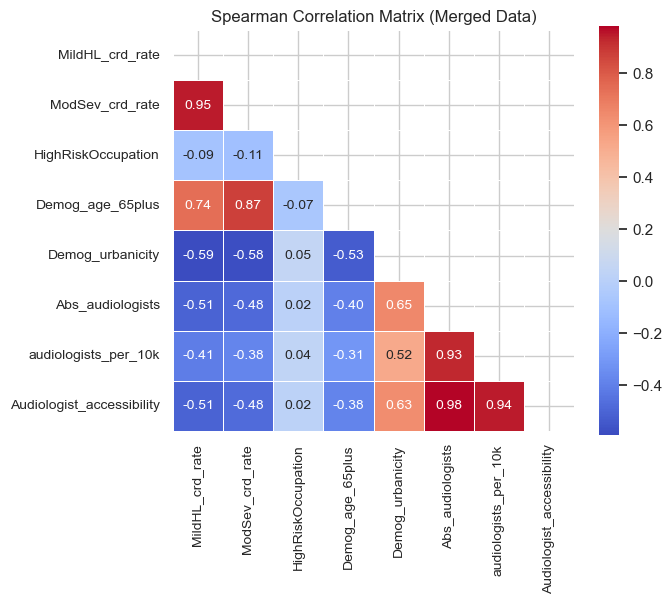

In [16]:
# Columns of interest
columns_of_interest = [
    'MildHL_crd_rate',
    'ModSev_crd_rate',
    'HighRiskOccupation',
    'Demog_age_65plus',
    'Demog_urbanicity',
    'Abs_audiologists',
    'audiologists_per_10k',
    'Audiologist_accessibility'
]

# Compute Spearman correlation matrix
spearman_corr_matrix = gdf[columns_of_interest].corr(method='spearman')

# Mask the upper triangle
mask = np.triu(np.ones_like(spearman_corr_matrix, dtype=bool))

# Set Seaborn style
sns.set(style="whitegrid")

# Create figure with adjusted size
plt.figure(figsize=(7, 6))

# Plot heatmap
ax = sns.heatmap(
    spearman_corr_matrix, 
    annot=True, 
    cmap='coolwarm', 
    linewidths=.5, 
    fmt=".2f",
    annot_kws={'size': 10},
    mask=mask,
    square=True
)

# Axis label formatting
plt.xticks(rotation=90)
plt.yticks(rotation=0)  
ax.tick_params(axis='x', labelsize=10)  
ax.tick_params(axis='y', labelsize=10)

# Add title
plt.title('Spearman Correlation Matrix (Merged Data)', fontsize=12)

plt.tight_layout()

save_dir = "/Users/dsabatus/Documents/Tianle/my_code/"
plt.savefig(os.path.join(save_dir, "Correlation_Matrix2.png"))

plt.show()


In [17]:
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point
from scipy.spatial import cKDTree
import numpy as np

#  Reproject gdf to a projected CRS for accurate distance calculations 
gdf_proj = gdf.to_crs(epsg=5070)  # NAD83 / Conus Albers for US

# Compute centroids in projected CRS (meters)
gdf_proj['centroid'] = gdf_proj.geometry.centroid
gdf_proj['centroid_x'] = gdf_proj.centroid.x
gdf_proj['centroid_y'] = gdf_proj.centroid.y

# 1. Split counties into two groups ---
with_audiologist = gdf_proj[gdf_proj['Abs_audiologists'] > 0].copy()
# Include counties with 0 audiologists OR missing data
without_audiologist = gdf_proj[(gdf_proj['Abs_audiologists'] == 0) | (gdf_proj['Abs_audiologists'].isna())].copy()

In [18]:
# Counties with audiologists
count_with = (gdf_proj['Abs_audiologists'] > 0).sum()

# Counties without audiologists (including NaN)
count_without = ((gdf_proj['Abs_audiologists'] == 0) | (gdf_proj['Abs_audiologists'].isna())).sum()

print(f"Counties with audiologists: {count_with}")
print(f"Counties without audiologists: {count_without}")

Counties with audiologists: 1384
Counties without audiologists: 1723


In [19]:
# 2. Approximate average within-county distance for counties with audiologists 
# Rough estimate: half of sqrt(area) in meters
with_audiologist['distance_within_county_m'] = 0.5 * np.sqrt(with_audiologist['AREA_SQMI'] * 2_589_988.11) 
# 1 sq mile = 2,589,988.11 m²

In [20]:
# 3. Compute distance to nearest county with audiologists for counties without 
# Build KDTree for fast nearest-neighbor search
tree = cKDTree(with_audiologist[['centroid_x', 'centroid_y']].values)

# Query nearest point for each county without audiologist
distances, indices = tree.query(without_audiologist[['centroid_x', 'centroid_y']].values)
without_audiologist['distance_to_nearest_m'] = distances  # in meters

In [21]:
# 4. Combine into single accessibility metric column 
# For counties with audiologists, use within-county distance
with_audiologist['drive_distance_m'] = with_audiologist['distance_within_county_m']

# For counties without audiologists, use distance to nearest county with audiologists
without_audiologist['drive_distance_m'] = without_audiologist['distance_to_nearest_m']

In [22]:
# Combine back into a single GeoDataFrame
gdf_proj['drive_distance_m'] = pd.concat([
    with_audiologist['drive_distance_m'],
    without_audiologist['drive_distance_m']
]).reindex(gdf_proj.index)

# Convert meters to miles
gdf_proj['drive_distance_miles'] = gdf_proj['drive_distance_m'] / 1609.34

# Check results 
print(gdf_proj[['Abs_audiologists', 'AREA_SQMI', 'centroid_x', 'centroid_y', 'drive_distance_miles']])

      Abs_audiologists     AREA_SQMI    centroid_x    centroid_y  \
0                  2.0    594.455838  8.726964e+05  1.094408e+06   
1                 17.0   1589.835294  7.897978e+05  8.845196e+05   
2                  0.0    885.007618  9.970151e+05  1.032941e+06   
3                  0.0    622.469288  8.228925e+05  1.141584e+06   
4                  2.0    644.890375  8.636912e+05  1.255732e+06   
...                ...           ...           ...           ...   
3102               0.0  10426.975770 -1.061535e+06  2.144842e+06   
3103               0.0   3996.846846 -1.162493e+06  2.416201e+06   
3104               1.0   2081.719808 -1.204269e+06  2.123542e+06   
3105               0.0   2238.678265 -9.325200e+05  2.381112e+06   
3106               0.0   2398.003892 -6.853686e+05  2.347409e+06   

      drive_distance_miles  
0                12.190763  
1                19.936419  
2                32.387177  
3                30.563847  
4                12.697377  
...      

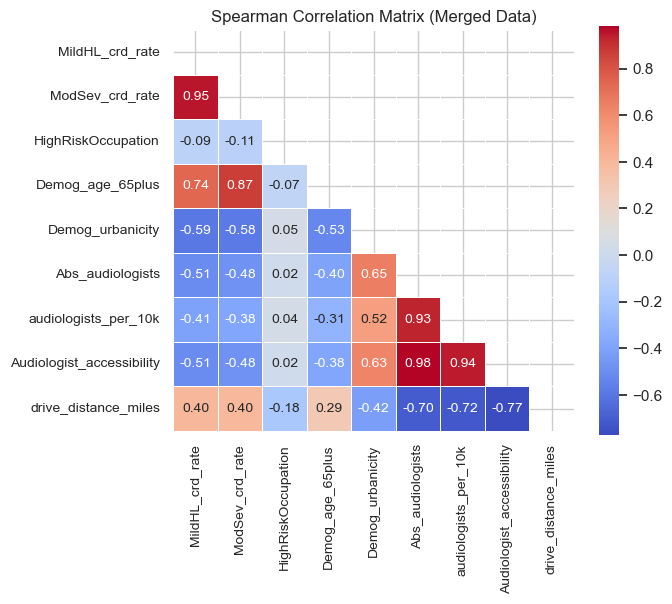

In [23]:
columns_of_interest = [
    'MildHL_crd_rate',
    'ModSev_crd_rate',
    'HighRiskOccupation',
    'Demog_age_65plus',
    'Demog_urbanicity',
    'Abs_audiologists',
    'audiologists_per_10k',
    'Audiologist_accessibility',
    'drive_distance_miles'
]

# Compute Spearman correlation matrix
spearman_corr_matrix = gdf_proj[columns_of_interest].corr(method='spearman')

# Mask the upper triangle
mask = np.triu(np.ones_like(spearman_corr_matrix, dtype=bool))

# Set Seaborn style
sns.set(style="whitegrid")

# Create figure with adjusted size
plt.figure(figsize=(7, 6))

# Plot heatmap
ax = sns.heatmap(
    spearman_corr_matrix, 
    annot=True, 
    cmap='coolwarm', 
    linewidths=.5, 
    fmt=".2f",
    annot_kws={'size': 10},
    mask=mask,
    square=True
)

# Axis label formatting
plt.xticks(rotation=90)
plt.yticks(rotation=0)  
ax.tick_params(axis='x', labelsize=10)  
ax.tick_params(axis='y', labelsize=10)

# Add title
plt.title('Spearman Correlation Matrix (Merged Data)', fontsize=12)

plt.tight_layout()

save_dir = "/Users/dsabatus/Documents/Tianle/my_code/"
plt.savefig(os.path.join(save_dir, "Correlation_Matrix3.png"))
plt.show()


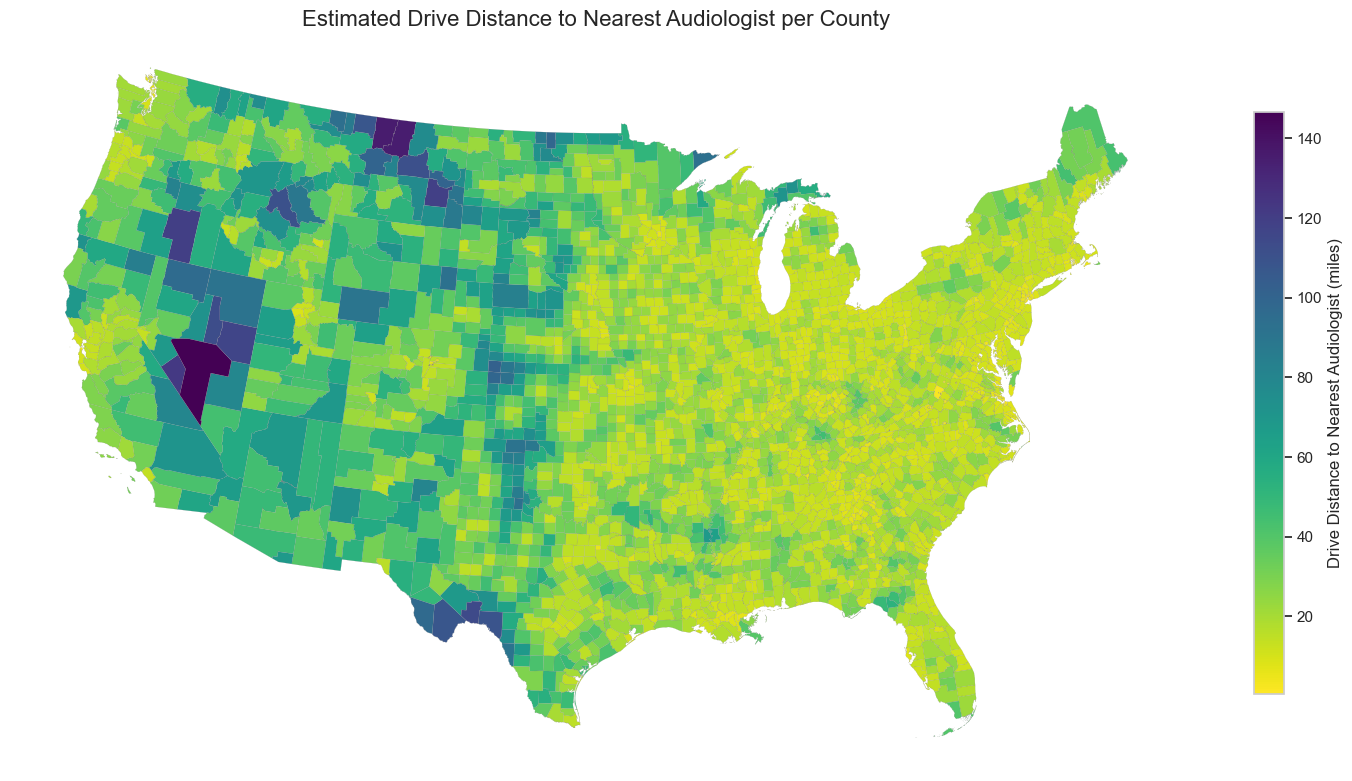

In [24]:
# Plot drive distances
fig, ax = plt.subplots(figsize=(15, 12))
gdf_proj.plot(
    column='drive_distance_miles',
    cmap='viridis_r',   # yellow = short distance, purple = long distance
    legend=True,
    edgecolor='gray',
    linewidth=0.1,
    ax=ax,
    legend_kwds={'shrink': 0.5, 'label': 'Drive Distance to Nearest Audiologist (miles)'}
)

plt.title("Estimated Drive Distance to Nearest Audiologist per County", fontsize=16)
plt.axis("off")
plt.tight_layout()
plt.show()

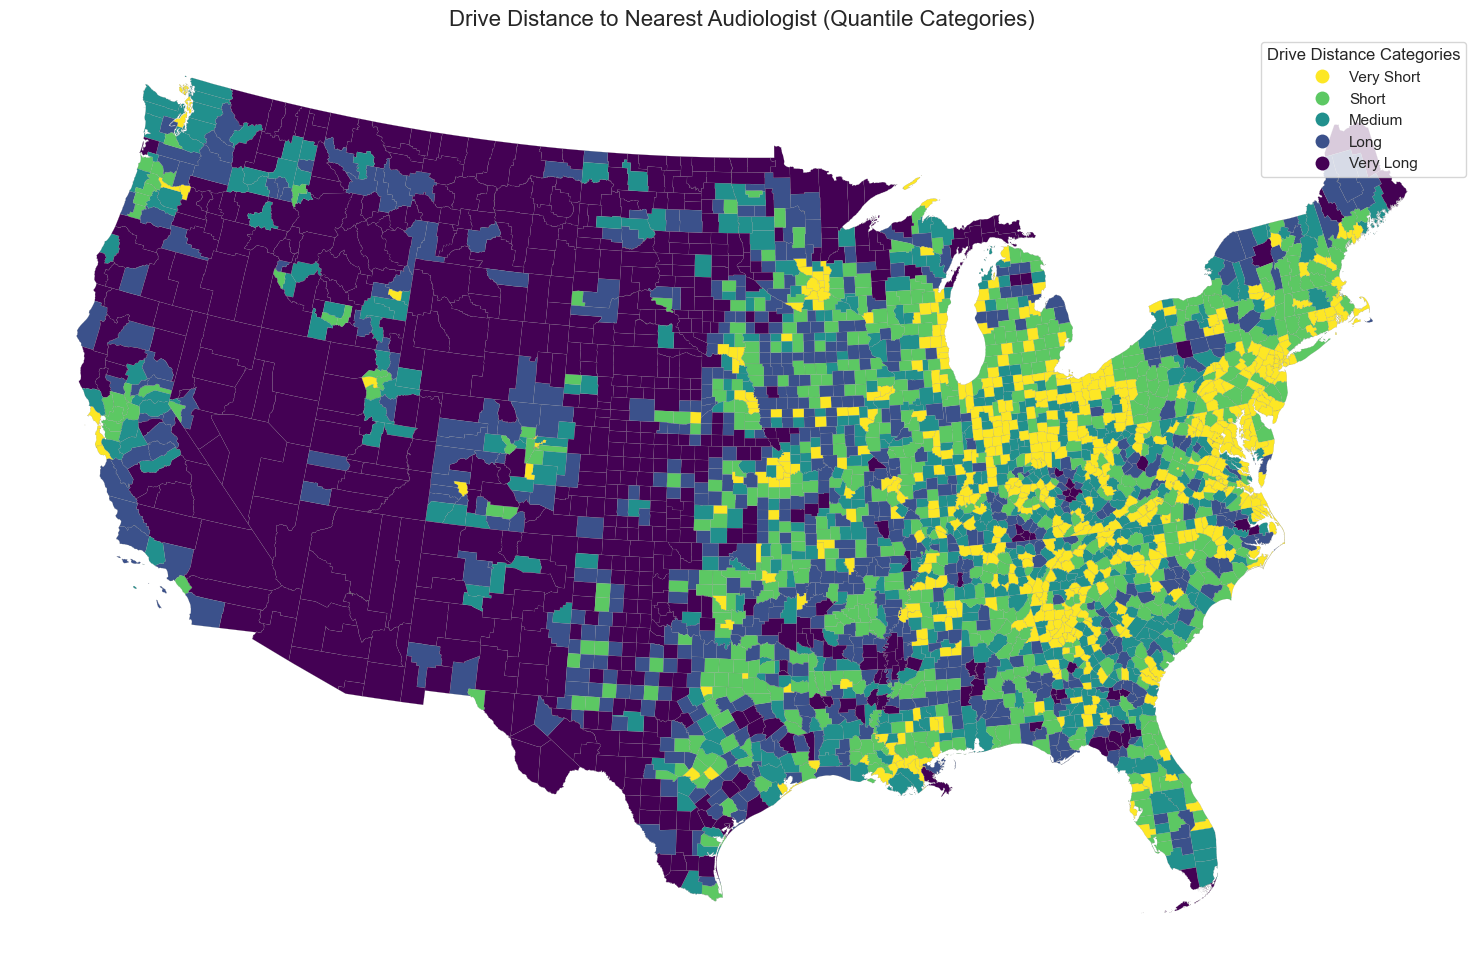

In [45]:
import matplotlib.pyplot as plt
import geopandas as gpd
import pandas as pd

# Create 5 quantile-based bins
gdf_proj['drive_distance_category'] = pd.qcut(
    gdf_proj['drive_distance_miles'],
    q=5,
    labels=["Very Short", "Short", "Medium", "Long", "Very Long"]
)

# Plot with categorical colors
fig, ax = plt.subplots(figsize=(15, 12))
gdf_proj.plot(
    column='drive_distance_category',
    categorical=True,
    legend=True,
    cmap='viridis_r',
    edgecolor='gray',
    linewidth=0.1,
    ax=ax,
    legend_kwds={'title': "Drive Distance Categories"}
)

plt.title("Drive Distance to Nearest Audiologist (Quantile Categories)", fontsize=16)
plt.axis("off")
plt.tight_layout()
plt.show()


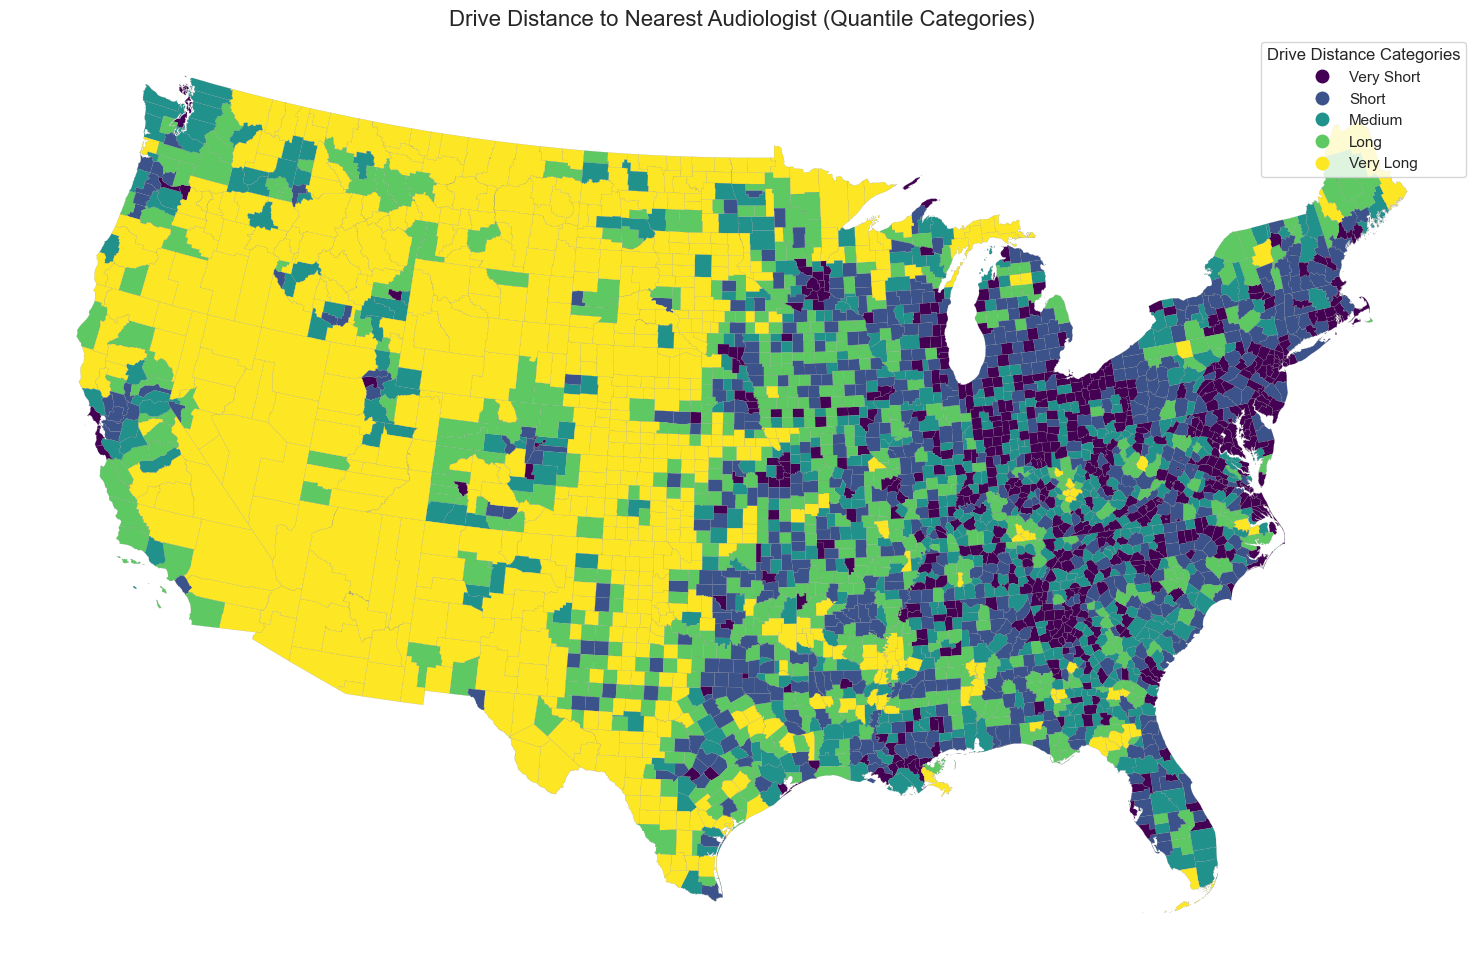

In [46]:
# Plot with reversed colormap
fig, ax = plt.subplots(figsize=(15, 12))
gdf_proj.plot(
    column='drive_distance_category',
    categorical=True,
    legend=True,
    cmap='viridis',   # <- not '_r', this makes the shortest distances darker
    edgecolor='gray',
    linewidth=0.1,
    ax=ax,
    legend_kwds={'title': "Drive Distance Categories"}
)

plt.title("Drive Distance to Nearest Audiologist (Quantile Categories)", fontsize=16)
plt.axis("off")
plt.tight_layout()
plt.show()


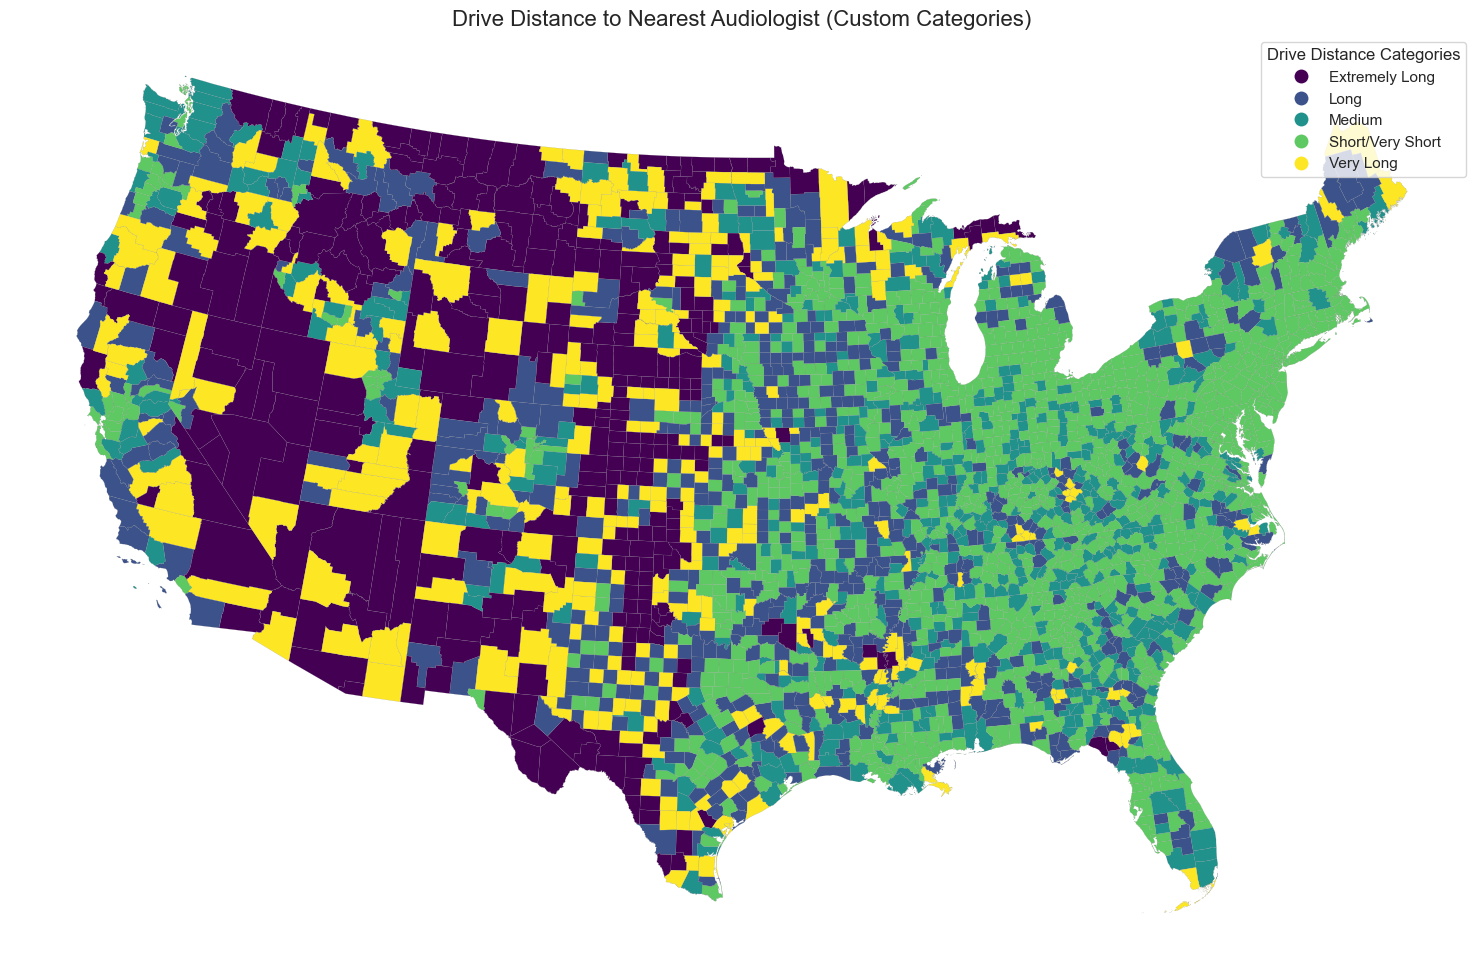

In [48]:
# Compute 5 quantiles
qcut_series = pd.qcut(gdf_proj['drive_distance_miles'], q=5)
bin_edges = qcut_series.cat.categories  # intervals with left/right bounds

# Function to assign categories
def categorize_drive_distance(x):
    if x <= bin_edges[1].right:   # first 40% (Q1 + Q2)
        return "Short/Very Short"
    elif x <= bin_edges[2].right: # Q3
        return "Medium"
    elif x <= bin_edges[3].right: # Q4
        return "Long"
    else:                         # Q5 split into two
        cutoff = gdf_proj.loc[gdf_proj['drive_distance_miles'] > bin_edges[3].right, 'drive_distance_miles'].median()
        return "Very Long" if x <= cutoff else "Extremely Long"

# Apply categorization
gdf_proj['drive_distance_category'] = gdf_proj['drive_distance_miles'].apply(categorize_drive_distance)

# Plot
fig, ax = plt.subplots(figsize=(15, 12))
gdf_proj.plot(
    column='drive_distance_category',
    categorical=True,
    legend=True,
    cmap='viridis',
    edgecolor='gray',
    linewidth=0.1,
    ax=ax,
    legend_kwds={'title': "Drive Distance Categories"}
)

plt.title("Drive Distance to Nearest Audiologist (Custom Categories)", fontsize=16)
plt.axis("off")
plt.tight_layout()
plt.show()


C:\Users\dsabatus\AppData\Local\Temp\ipykernel_10636\3354665456.py:58: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('viridis')  # viridis: dark -> light


Quantile cutoffs (miles):
  0th  pctile: 0.57
 20th  pctile: 11.86
 40th  pctile: 16.11  <-- Short/Very Short <= this
 60th  pctile: 23.34  <-- Medium <= this
 80th  pctile: 33.05  <-- Long <= this
 100th pctile: 146.70
Top-20% median cutoff (miles): 47.30  <-- split between Very Long and Extremely Long


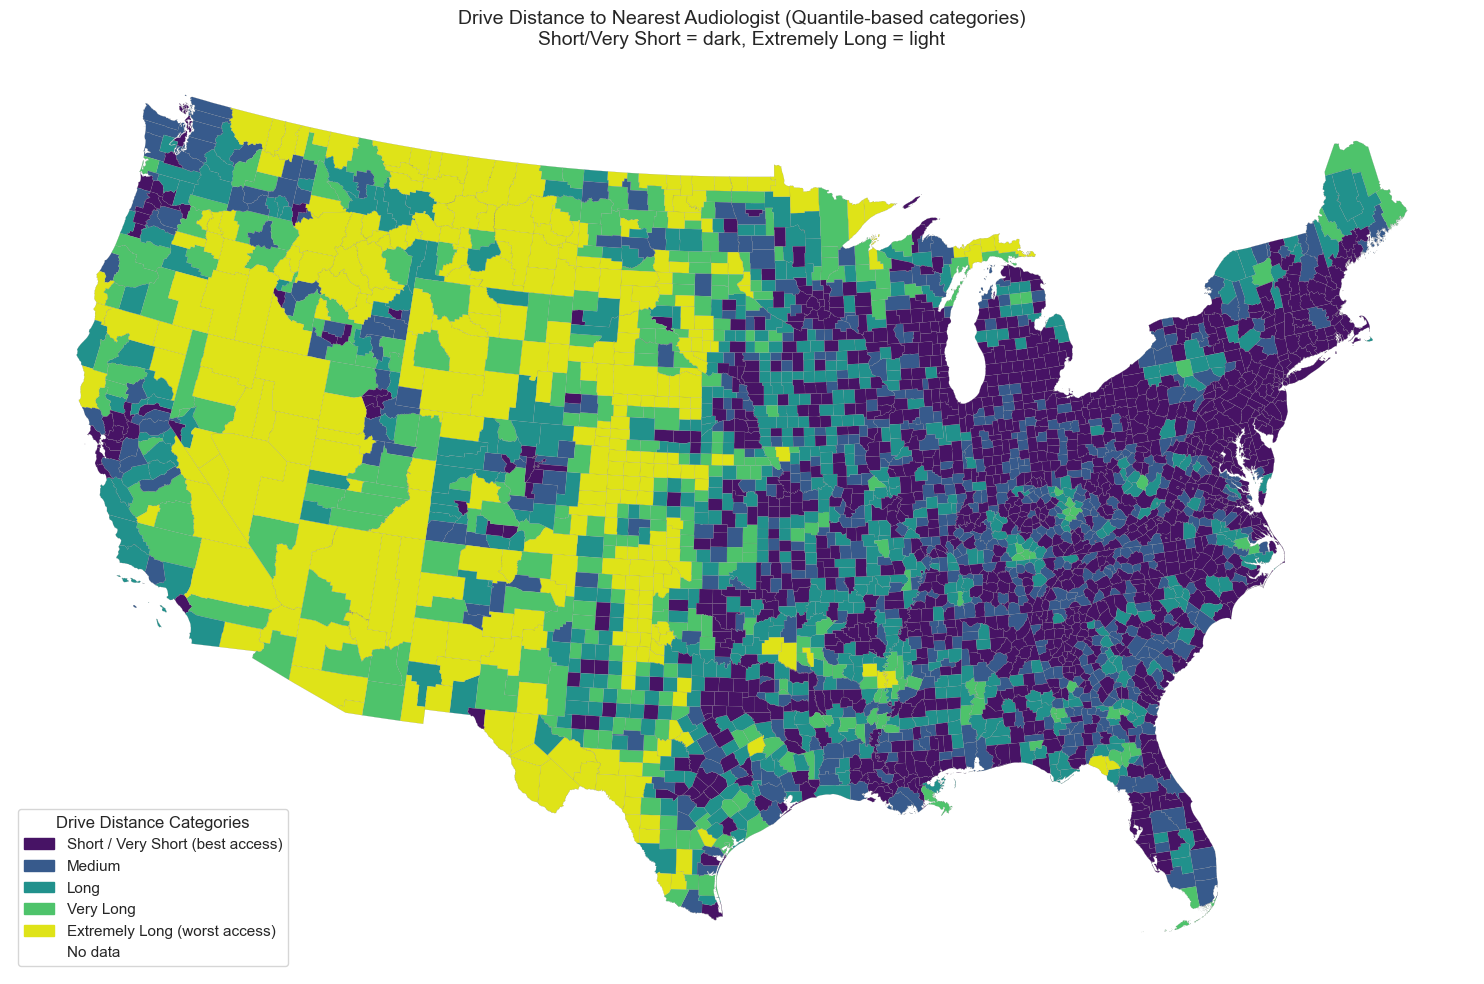

In [26]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.cm as cm

# --- Ensure you have a drive distance column in miles ---
# Try existing names and create drive_distance_miles if necessary
if 'drive_distance_miles' in gdf_proj.columns:
    miles = gdf_proj['drive_distance_miles']
elif 'drive_distance_m' in gdf_proj.columns:
    miles = gdf_proj['drive_distance_m'] / 1609.34
elif 'distance_to_nearest_m' in gdf_proj.columns:
    miles = gdf_proj['distance_to_nearest_m'] / 1609.34
elif 'distance_to_nearest' in gdf_proj.columns:
    # if distance_to_nearest is meters (common in previous code), convert
    miles = gdf_proj['distance_to_nearest'] / 1609.34
else:
    raise KeyError("No distance column found. Expected one of: 'drive_distance_miles', 'drive_distance_m', 'distance_to_nearest_m', 'distance_to_nearest'.")

# attach (safe) copy
gdf_proj = gdf_proj.copy()
gdf_proj['drive_distance_miles'] = miles

# --- compute quantile cutpoints (drop NaNs) ---
vals = gdf_proj['drive_distance_miles'].dropna().values
if len(vals) == 0:
    raise ValueError("drive_distance_miles contains only NaN values.")

percentiles = np.percentile(vals, [0, 20, 40, 60, 80, 100])   # edges for 5 quantiles
p0, p20, p40, p60, p80, p100 = percentiles

# median of the top 20% (for splitting the top bin into two)
top20_mask = gdf_proj['drive_distance_miles'] > p80
if top20_mask.any():
    top20_median = gdf_proj.loc[top20_mask, 'drive_distance_miles'].median()
else:
    # fallback if nothing in top20 (unlikely)
    top20_median = (p80 + p100) / 2.0

# --- assign categories ---
def categorize_drive_distance_val(x):
    if pd.isna(x):
        return 'NoData'
    if x <= p40:               # first two quintiles combined (0-40%)
        return 'Short/Very Short'
    elif x <= p60:             # 40-60%
        return 'Medium'
    elif x <= p80:             # 60-80%
        return 'Long'
    else:                      # >80%  -> split into Very Long / Extremely Long by median of top20
        return 'Very Long' if x <= top20_median else 'Extremely Long'

import pandas as pd
gdf_proj['drive_distance_category'] = gdf_proj['drive_distance_miles'].apply(categorize_drive_distance_val)

# --- prepare colors: shortest = darkest, longest = lightest ---
# sample a sequential colormap (viridis) from dark -> light
cmap = cm.get_cmap('viridis')  # viridis: dark -> light
# sample five distinct positions from dark to light
sample_positions = [0.05, 0.28, 0.50, 0.72, 0.95]
sampled_colors = [cmap(pos) for pos in sample_positions]

# ordered categories (ensure order matches darkest -> lightest)
ordered_cats = ['Short/Very Short', 'Medium', 'Long', 'Very Long', 'Extremely Long']

color_map = {cat: sampled_colors[i] for i, cat in enumerate(ordered_cats)}
color_map['NoData'] = (1.0, 1.0, 1.0, 1.0)  # white for missing

# --- map colors and plot ---
color_series = gdf_proj['drive_distance_category'].map(color_map)

fig, ax = plt.subplots(figsize=(15, 12))
gdf_proj.plot(
    color=color_series,
    edgecolor='gray',
    linewidth=0.1,
    ax=ax
)

# Build legend patches in the desired order with human-friendly labels
legend_patches = [
    mpatches.Patch(color=color_map['Short/Very Short'], label='Short / Very Short (best access)'),
    mpatches.Patch(color=color_map['Medium'], label='Medium'),
    mpatches.Patch(color=color_map['Long'], label='Long'),
    mpatches.Patch(color=color_map['Very Long'], label='Very Long'),
    mpatches.Patch(color=color_map['Extremely Long'], label='Extremely Long (worst access)'),
    mpatches.Patch(color=color_map['NoData'], label='No data')
]

ax.legend(handles=legend_patches, title='Drive Distance Categories', loc='lower left', frameon=True)

ax.set_title("Drive Distance to Nearest Audiologist (Quantile-based categories)\nShort/Very Short = dark, Extremely Long = light", fontsize=14)
ax.axis('off')
plt.tight_layout()


# --- Print numeric cutoffs for transparency ---
print("Quantile cutoffs (miles):")
print(f"  0th  pctile: {p0:.2f}")
print(f" 20th  pctile: {p20:.2f}")
print(f" 40th  pctile: {p40:.2f}  <-- Short/Very Short <= this")
print(f" 60th  pctile: {p60:.2f}  <-- Medium <= this")
print(f" 80th  pctile: {p80:.2f}  <-- Long <= this")
print(f" 100th pctile: {p100:.2f}")
print(f"Top-20% median cutoff (miles): {top20_median:.2f}  <-- split between Very Long and Extremely Long")

save_dir = "/Users/dsabatus/Documents/Tianle/my_code/"
plt.savefig(os.path.join(save_dir, "Audiologist_map_final.png"))

plt.show()


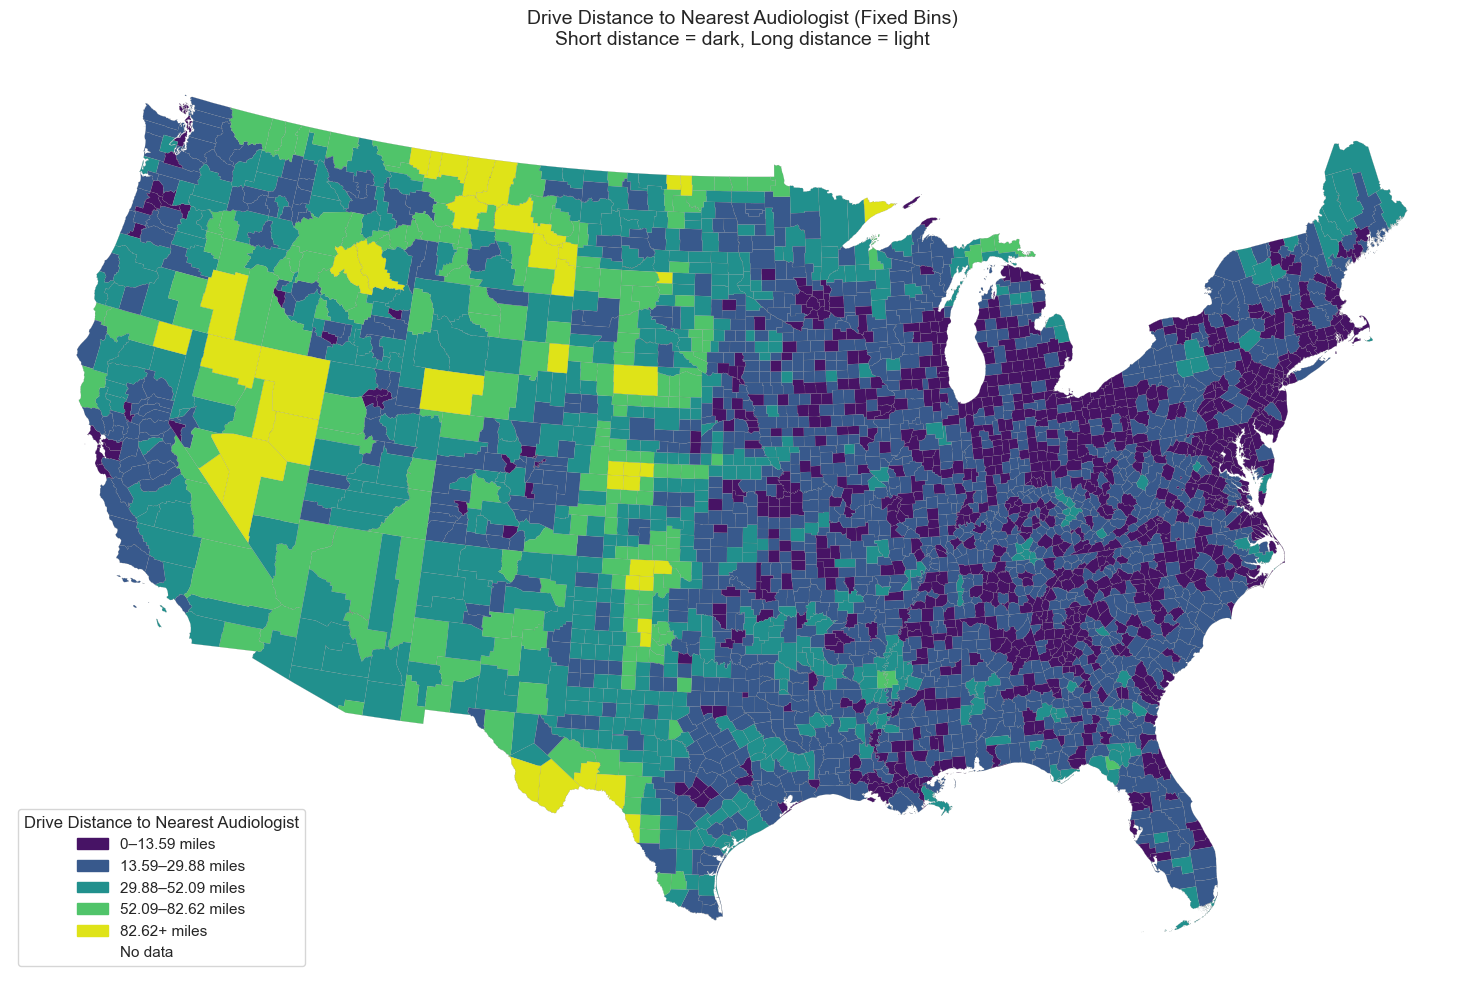

In [31]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.cm as cm
import pandas as pd

# --- Ensure you have a drive distance column in miles ---
if 'drive_distance_miles' in gdf_proj.columns:
    miles = gdf_proj['drive_distance_miles']
elif 'drive_distance_m' in gdf_proj.columns:
    miles = gdf_proj['drive_distance_m'] / 1609.34
elif 'distance_to_nearest_m' in gdf_proj.columns:
    miles = gdf_proj['distance_to_nearest_m'] / 1609.34
elif 'distance_to_nearest' in gdf_proj.columns:
    miles = gdf_proj['distance_to_nearest'] / 1609.34
else:
    raise KeyError("No distance column found.")

gdf_proj = gdf_proj.copy()
gdf_proj['drive_distance_miles'] = miles.astype(float)

# --- Fixed bins (miles) and labels ---
bins = [0, 13.59, 29.88, 52.09, 82.62, np.inf]
labels = [
    "0–13.59 miles",
    "13.59–29.88 miles",
    "29.88–52.09 miles",
    "52.09–82.62 miles",
    "82.62+ miles"
]

# --- Categorize distances ---
gdf_proj['drive_distance_category'] = pd.cut(
    gdf_proj['drive_distance_miles'],
    bins=bins,
    labels=labels,
    include_lowest=True
).astype(str)   # 👈 force to string to avoid MultiIndex issues

# --- Sample viridis colormap (dark -> light) ---
cmap = plt.get_cmap('viridis')   # modern way, avoids deprecation
sample_positions = np.linspace(0.05, 0.95, len(labels))  
sampled_colors = [cmap(pos) for pos in sample_positions]

# Map categories to hex colors instead of tuples
from matplotlib.colors import to_hex

color_map = {label: to_hex(sampled_colors[i]) for i, label in enumerate(labels)}
color_map['NoData'] = "#FFFFFF"  # white

# Safe mapping
gdf_proj['color'] = gdf_proj['drive_distance_category'].map(color_map).fillna(color_map['NoData'])


# --- Plot ---
fig, ax = plt.subplots(figsize=(15, 12))
gdf_proj.plot(
    color=gdf_proj['color'],
    edgecolor='gray',
    linewidth=0.1,
    ax=ax
)

# --- Legend ---
legend_patches = [mpatches.Patch(color=color_map[label], label=label) for label in labels]
legend_patches.append(mpatches.Patch(color=color_map['NoData'], label="No data"))

ax.legend(handles=legend_patches, title="Drive Distance to Nearest Audiologist", 
          loc='lower left', frameon=True, facecolor="white")  # solid white legend bg

ax.set_title("Drive Distance to Nearest Audiologist (Fixed Bins)\nShort distance = dark, Long distance = light", fontsize=14)
ax.axis("off")
plt.tight_layout()

# Save before show
save_dir = "/Users/dsabatus/Documents/Tianle/my_code/"
plt.savefig(os.path.join(save_dir, "Audiologist_map_fixedbins.png"), dpi=300, bbox_inches="tight")

plt.show()